# PneumoFusionNet — Pilot Architecture on Scale-Up Dataset
## Phase 1.1 (ResNet50 + DSC + GCSA) — 1,989 PA-Only Images

### Purpose
This notebook applies the **exact pilot architecture** (ResNet50 + DSC + GCSA) from the
139-sample pilot study to the full 1,989-sample PA-only scale-up dataset.

This is the **baseline/reference experiment** for the scale-up phase — it establishes
how the pilot architecture performs with more data, before switching to DenseNet-121.

### Key differences vs pilot notebook
| Config | Pilot (139 samples) | This notebook (1,989 samples) |
|--------|--------------------|---------------------------------|
| Dataset | `mimic_dataset.csv` (all views) | `mimic_paired_dataset.csv` (PA-only) |
| Samples | 139 (118N + 21P) | **1,989 (1,062N + 927P)** |
| Split | Row-level stratified | **Patient-level GroupShuffleSplit** |
| Imbalance fix | Weighted CE loss | **WeightedRandomSampler + Weighted CE** |
| Architecture | ResNet50 + DSC + GCSA | **Same (identical)** |

### Architecture
- ResNet50 backbone (ImageNet pretrained, grayscale adapted)
- Depthwise Separable Convolution (DSC): 2048 → 1024 channels
- Global Context Spatial Attention (GCSA): channel + spatial attention
- GlobalAvgPool → Dropout(0.5) → FC(1024→512) → ReLU → Dropout(0.3) → FC(512→2)

In [1]:
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc
)
from collections import Counter

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Memory: 4.294508544 GB


## Step 1: Paths & Hyperparameters

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = r'C:\2026\PneumoFusionNet\mimic\1000_dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1_pilot_arch_scaleUp_ResNet')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_pilot_arch_scaleup.pth')

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Hyperparameters (identical to pilot Phase 1.1) ───────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16      # increased from 8 (more data → stable gradients)
NUM_EPOCHS    = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 2
WARMUP_EPOCHS = 3
GRAD_CLIP     = 1.0
CLASSES       = ['NORMAL', 'PNEUMONIA']

# ── Split ratios ─────────────────────────────────────────────────────────────
VAL_RATIO  = 0.15   # 15% validation
TEST_RATIO = 0.15   # 15% test

print('CSV path :', CSV_PATH)
print('Exists   :', os.path.exists(CSV_PATH))
print('Save dir :', SAVE_DIR)

CSV path : C:\2026\PneumoFusionNet\mimic\1000_dataset\mimic_paired_dataset.csv
Exists   : True
Save dir : C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_pilot_arch_scaleUp_ResNet


## Step 2: Load Dataset (PA-Only, Patient-Level Split)

**Critical difference from pilot:** We use `GroupShuffleSplit` on `subject_id`
to guarantee that no patient appears in both train and test sets.
The pilot used row-level splits — a known limitation.

In [3]:
df_raw = pd.read_csv(CSV_PATH)
print(f'Raw CSV shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

# ── Filter to PA-only views ───────────────────────────────────────────────────
df = df_raw[df_raw['view_position'] == 'PA'].copy().reset_index(drop=True)
print(f'\nPA-only shape: {df.shape}')

# ── Build binary label: 1 = Pneumonia, 0 = Normal ────────────────────────────
df['label'] = df['pneumonia_label'].apply(lambda x: 1 if x == 1.0 else 0)
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Pneumonia'})

# ── Build absolute image path ─────────────────────────────────────────────────
df['abs_image_path'] = df['image_path'].apply(
    lambda p: os.path.join(BASE_DIR, p.replace('/', os.sep))
)

# ── Verify images exist ───────────────────────────────────────────────────────
missing = df['abs_image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Total PA samples : {len(df)}')
print(f'Images found     : {len(df) - missing} / {len(df)}')
if missing > 0:
    print(f'WARNING: {missing} missing images!')
    print('Sample missing:', df[~df["abs_image_path"].apply(os.path.exists)]['abs_image_path'].iloc[0])
else:
    print('All images found!')

print('\nClass distribution (PA, all):')
print(df['label_name'].value_counts())

print('\nSample rows:')
print(df[['subject_id', 'label', 'label_name', 'abs_image_path']].head(3))

Raw CSV shape: (3221, 9)
Columns: ['patient_id', 'subject_id', 'study_id', 'image_name', 'image_path', 'report_path', 'view_position', 'pneumonia_label', 'no_finding_label']

PA-only shape: (1989, 9)
Total PA samples : 1989
Images found     : 1989 / 1989
All images found!

Class distribution (PA, all):
Normal       1062
Pneumonia     927
Name: label_name, dtype: int64

Sample rows:
   subject_id  label label_name  \
0    15653537      1  Pneumonia   
1    11173142      1  Pneumonia   
2    14472543      0     Normal   

                                      abs_image_path  
0  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...  
1  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...  
2  C:\2026\PneumoFusionNet\mimic\1000_dataset\res...  


In [4]:
# ── Patient-level GroupShuffleSplit ───────────────────────────────────────────
# Step 1: Split off TEST set (patient-level)
gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['subject_id']))

df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
df_test     = df.iloc[test_idx].reset_index(drop=True)

# Step 2: Split TRAINVAL into TRAIN + VAL (patient-level)
val_ratio_adjusted = VAL_RATIO / (1 - TEST_RATIO)   # relative val size
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_ratio_adjusted, random_state=SEED)
train_idx, val_idx = next(gss_val.split(df_trainval, df_trainval['label'],
                                         groups=df_trainval['subject_id']))

df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
df_val   = df_trainval.iloc[val_idx].reset_index(drop=True)

# ── Verify no patient overlap ─────────────────────────────────────────────────
train_patients = set(df_train['subject_id'])
val_patients   = set(df_val['subject_id'])
test_patients  = set(df_test['subject_id'])

train_val_overlap  = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap   = val_patients   & test_patients

print('=== Patient-Level Split Summary ===')
print(f'Train : {len(df_train):4d} images | {len(train_patients):4d} patients | '
      f'Pneumonia={df_train["label"].sum()} Normal={(df_train["label"]==0).sum()}')
print(f'Val   : {len(df_val):4d} images | {len(val_patients):4d} patients | '
      f'Pneumonia={df_val["label"].sum()} Normal={(df_val["label"]==0).sum()}')
print(f'Test  : {len(df_test):4d} images | {len(test_patients):4d} patients | '
      f'Pneumonia={df_test["label"].sum()} Normal={(df_test["label"]==0).sum()}')
print(f'\nPatient overlap checks:')
print(f'  Train ∩ Val  = {len(train_val_overlap)}  (must be 0)')
print(f'  Train ∩ Test = {len(train_test_overlap)} (must be 0)')
print(f'  Val   ∩ Test = {len(val_test_overlap)}  (must be 0)')

=== Patient-Level Split Summary ===
Train : 1401 images | 1294 patients | Pneumonia=664 Normal=737
Val   :  295 images |  278 patients | Pneumonia=140 Normal=155
Test  :  293 images |  278 patients | Pneumonia=123 Normal=170

Patient overlap checks:
  Train ∩ Val  = 0  (must be 0)
  Train ∩ Test = 0 (must be 0)
  Val   ∩ Test = 0  (must be 0)


## Step 3: Dataset & DataLoader

In [5]:
# ── Augmentation ──────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# ── Dataset Class ─────────────────────────────────────────────────────────────
class MIMICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        img   = Image.open(row['abs_image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


train_dataset = MIMICDataset(df_train, transform=train_transforms)
val_dataset   = MIMICDataset(df_val,   transform=val_transforms)
test_dataset  = MIMICDataset(df_test,  transform=val_transforms)

# ── WeightedRandomSampler for class imbalance ─────────────────────────────────
train_labels = df_train['label'].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'Class counts  — Normal: {class_counts[0]}, Pneumonia: {class_counts[1]}')
print(f'Class weights — Normal: {class_weights[0]:.4f}, Pneumonia: {class_weights[1]:.4f}')

Train batches: 88 | Val batches: 19 | Test batches: 19
Class counts  — Normal: 737, Pneumonia: 664
Class weights — Normal: 0.0014, Pneumonia: 0.0015


## Step 4: Model — Pilot Architecture (ResNet50 + DSC + GCSA)

Identical to `Phase-1.1-image_classifier(balanced-Set).ipynb` in the pilot.

In [6]:
# ── Depthwise Separable Convolution (DSC) ─────────────────────────────────────
class DepthwiseSeparableConv(nn.Module):
    """2048 → 1024 channels with ~50% fewer parameters than standard conv."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.depthwise  = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                    padding=1, groups=in_channels, bias=False)
        self.pointwise  = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn         = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.activation(x)


# ── Global Context Spatial Attention (GCSA) ───────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg = self.mlp(self.avg_pool(x).view(b, c))
        mx  = self.mlp(self.max_pool(x).view(b, c))
        return self.sigmoid((avg + mx).view(b, c, 1, 1))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_ch = x.mean(dim=1, keepdim=True)
        max_ch = x.max(dim=1, keepdim=True).values
        return self.sigmoid(self.conv(torch.cat([avg_ch, max_ch], dim=1)))


class GCSA(nn.Module):
    """Global Context Spatial Attention: channel + spatial attention combined."""
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(kernel_size=7)

    def forward(self, x):
        x = x * self.channel_att(x)  # A_ch
        x = x * self.spatial_att(x)  # A_sp
        return x


# ── Full Pilot Architecture ───────────────────────────────────────────────────
class PneumoFusionNetPilot(nn.Module):
    """
    Exact pilot architecture from Phase-1.1-image_classifier(balanced-Set).ipynb.
    ResNet50 (ImageNet, grayscale-adapted) + DSC + GCSA + Classifier head.
    """
    def __init__(self, num_classes=2, freeze_layers=7):
        super().__init__()

        # ── ResNet50 backbone ─────────────────────────────────────────────────
        resnet = models.resnet50(pretrained=True)

        # Adapt first conv for grayscale (1 channel) by averaging RGB weights
        orig_weight = resnet.conv1.weight.data  # [64, 3, 7, 7]
        new_conv1   = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        new_conv1.weight.data = orig_weight.mean(dim=1, keepdim=True)
        resnet.conv1 = new_conv1

        # Freeze early layers
        children = list(resnet.children())
        for layer in children[:freeze_layers]:
            for param in layer.parameters():
                param.requires_grad = False

        # Remove avgpool and fc — we'll do our own
        self.backbone = nn.Sequential(*children[:-2])  # up to layer4

        # ── DSC: 2048 → 1024 ─────────────────────────────────────────────────
        self.dsc = DepthwiseSeparableConv(2048, 1024)

        # ── GCSA attention ────────────────────────────────────────────────────
        self.gcsa = GCSA(1024, reduction_ratio=16)

        # ── Global Average Pooling → Classifier head ──────────────────────────
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)   # [B, 2048, 7, 7]
        feat = self.dsc(feat)     # [B, 1024, 7, 7]
        feat = self.gcsa(feat)    # [B, 1024, 7, 7]
        feat = self.gap(feat)     # [B, 1024, 1, 1]
        feat = feat.view(feat.size(0), -1)  # [B, 1024]
        return self.classifier(feat)


# ── Instantiate & verify ──────────────────────────────────────────────────────
model = PneumoFusionNetPilot(num_classes=NUM_CLASSES, freeze_layers=7).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Quick forward-pass check
with torch.no_grad():
    dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape: {out.shape}  (expected: [2, 2])')

Total parameters    : 26,276,388
Trainable parameters: 17,739,364
Output shape: torch.Size([2, 2])  (expected: [2, 2])


## Step 5: Loss, Optimizer & Scheduler

In [7]:
# ── Weighted CrossEntropy (class-imbalance aware) ─────────────────────────────
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ── Scheduler: Linear warmup → CosineAnnealing ───────────────────────────────
warmup_scheduler  = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                              total_iters=WARMUP_EPOCHS)
cosine_scheduler  = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler         = SequentialLR(optimizer,
                                  schedulers=[warmup_scheduler, cosine_scheduler],
                                  milestones=[WARMUP_EPOCHS])

print('Loss     :', criterion)
print('Optimizer:', optimizer)
print('Scheduler: LinearLR warmup (3 ep) → CosineAnnealingLR')

Loss     : CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001
)
Scheduler: LinearLR warmup (3 ep) → CosineAnnealingLR


## Step 6: Training Loop

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / total
    avg_acc  = correct / total
    auc_score = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, avg_acc, auc_score, all_probs, all_labels


# ── Training ──────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   [], 'val_auc': []}

best_val_auc = 0.0
best_state   = None

print(f'Training {NUM_EPOCHS} epochs on {len(train_dataset)} samples...\n')
print(f'{"Epoch":>5}  {"TrainLoss":>10}  {"TrainAcc":>9}  '
      f'{"ValLoss":>8}  {"ValAcc":>8}  {"ValAUC":>8}  {"LR":>10}')
print('-' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_auc'].append(vl_auc)

    current_lr = optimizer.param_groups[0]['lr']

    flag = ''
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        best_state   = copy.deepcopy(model.state_dict())
        torch.save(best_state, MODEL_PATH)
        flag = '  ← best'

    print(f'{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.4f}  '
          f'{vl_loss:>8.4f}  {vl_acc:>8.4f}  {vl_auc:>8.4f}  '
          f'{current_lr:>10.2e}{flag}')

print(f'\nBest Val AUC: {best_val_auc:.4f}')
print(f'Model saved : {MODEL_PATH}')

Training 50 epochs on 1401 samples...

Epoch   TrainLoss   TrainAcc   ValLoss    ValAcc    ValAUC          LR
---------------------------------------------------------------------------
    1      0.6876    0.5639    0.6822    0.6746    0.7690    4.00e-05  ← best
    2      0.6214    0.6681    0.5588    0.7424    0.8073    7.00e-05  ← best
    3      0.5456    0.7131    0.5625    0.7220    0.8035    1.00e-04
    4      0.5197    0.7466    0.5871    0.7220    0.7953    9.99e-05
    5      0.4763    0.7695    0.6077    0.7186    0.7852    9.96e-05
    6      0.4305    0.8080    0.6002    0.7186    0.7957    9.90e-05
    7      0.4062    0.8223    0.7015    0.6983    0.7794    9.82e-05
    8      0.3602    0.8437    0.6998    0.7322    0.8008    9.73e-05
    9      0.3502    0.8465    0.8354    0.6881    0.7913    9.61e-05
   10      0.3018    0.8858    0.9886    0.6814    0.7824    9.47e-05
   11      0.2994    0.8701    0.7992    0.6780    0.7696    9.31e-05
   12      0.3262    0.8715 

## Step 7: Training History Plots

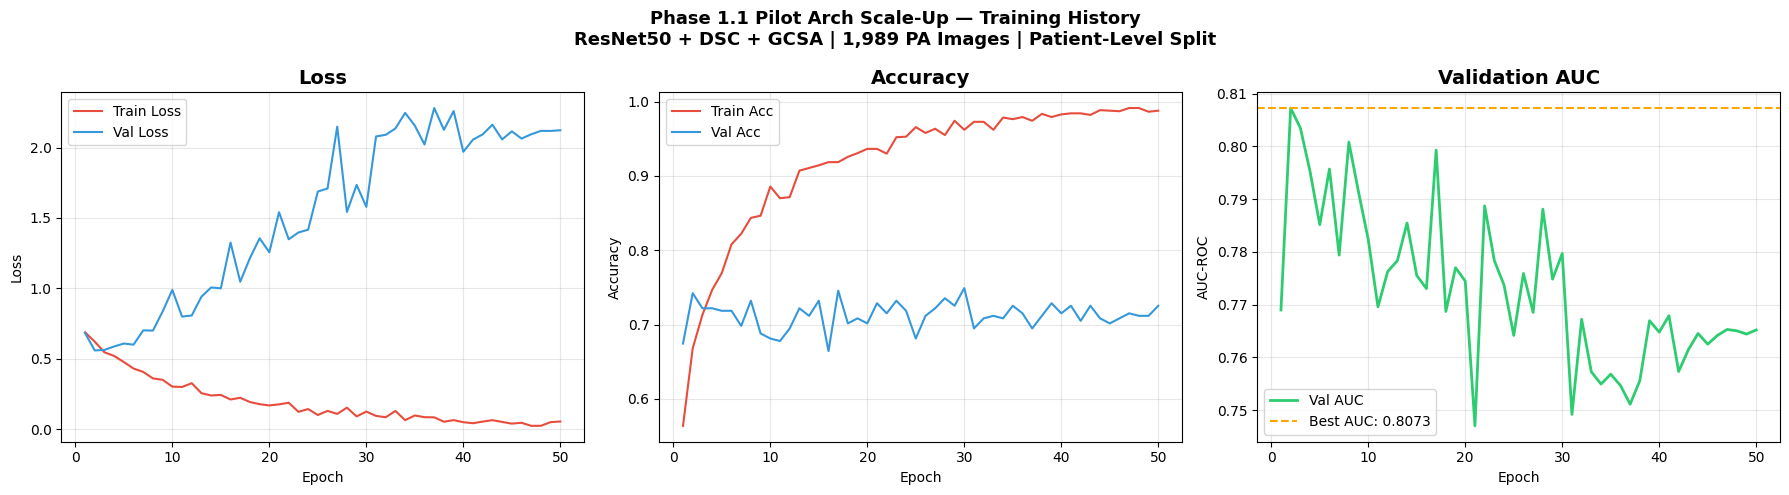

Saved: training_history.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#E74C3C')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#3498DB')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='#E74C3C')
axes[1].plot(epochs, history['val_acc'],   label='Val Acc',   color='#3498DB')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_auc'], label='Val AUC', color='#2ECC71', linewidth=2)
axes[2].axhline(y=best_val_auc, color='orange', linestyle='--',
                label=f'Best AUC: {best_val_auc:.4f}')
axes[2].set_title('Validation AUC', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC-ROC')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 1.1 Pilot Arch Scale-Up — Training History\n'
             'ResNet50 + DSC + GCSA | 1,989 PA Images | Patient-Level Split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

## Step 8: Test Set Evaluation (Best Model)

In [10]:
# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

_, test_acc, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion)

test_preds = [1 if p >= 0.5 else 0 for p in test_probs]

print('=' * 55)
print('TEST SET RESULTS — Phase 1.1 Pilot Arch Scale-Up')
print('Architecture : ResNet50 + DSC + GCSA (pilot, unchanged)')
print('Dataset      : 1,989 PA-only images, patient-level split')
print('=' * 55)
print(f'AUC-ROC      : {test_auc:.4f}')
print(f'Accuracy     : {test_acc:.4f} ({test_acc*100:.1f}%)')

cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(test_labels, test_preds, average='macro')

print(f'Sensitivity  : {sensitivity:.4f} ({sensitivity*100:.1f}%)  [Pneumonia Recall]')
print(f'Specificity  : {specificity:.4f} ({specificity*100:.1f}%)  [Normal Recall]')
print(f'F1 (macro)   : {f1:.4f}')
print(f'Test samples : {len(test_labels)} (N={test_labels.count(0)}, P={test_labels.count(1)})')
print()
print('Classification Report:')
print(classification_report(test_labels, test_preds,
                             target_names=CLASSES, digits=4))

TEST SET RESULTS — Phase 1.1 Pilot Arch Scale-Up
Architecture : ResNet50 + DSC + GCSA (pilot, unchanged)
Dataset      : 1,989 PA-only images, patient-level split
AUC-ROC      : 0.7126
Accuracy     : 0.6621 (66.2%)
Sensitivity  : 0.6992 (69.9%)  [Pneumonia Recall]
Specificity  : 0.6353 (63.5%)  [Normal Recall]
F1 (macro)   : 0.6602
Test samples : 293 (N=170, P=123)

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.7448    0.6353    0.6857       170
   PNEUMONIA     0.5811    0.6992    0.6347       123

    accuracy                         0.6621       293
   macro avg     0.6630    0.6672    0.6602       293
weighted avg     0.6761    0.6621    0.6643       293



## Step 9: Confusion Matrix

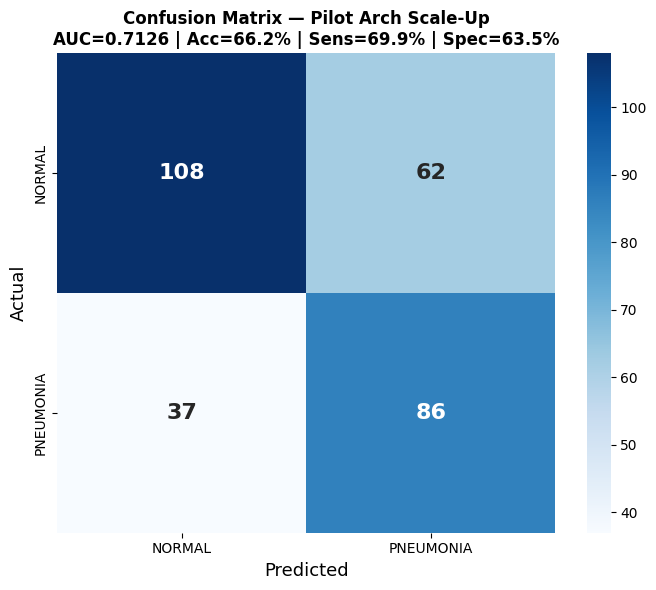

Saved: confusion_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={'size': 16, 'weight': 'bold'}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual',    fontsize=13)
ax.set_title(
    f'Confusion Matrix — Pilot Arch Scale-Up\n'
    f'AUC={test_auc:.4f} | Acc={test_acc*100:.1f}% | '
    f'Sens={sensitivity*100:.1f}% | Spec={specificity*100:.1f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## Step 10: ROC Curve

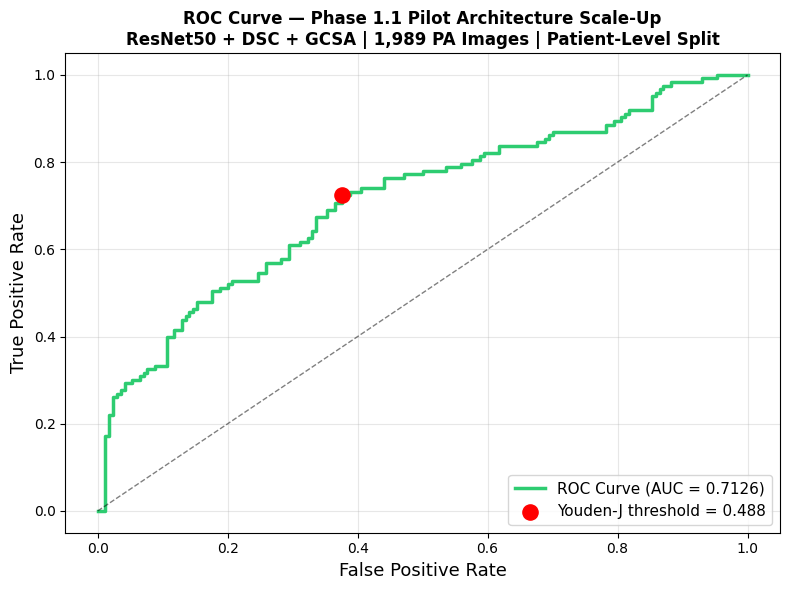

ROC AUC            : 0.7126
Youden-J threshold : 0.4879

With Youden-J threshold (0.488):
  Accuracy    : 0.6655 (66.6%)
  Sensitivity : 0.7236 (72.4%)
  Specificity : 0.6235 (62.4%)
Saved: roc_curve.png


In [12]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

# Youden's J optimal threshold
j_scores = tpr - fpr
opt_idx  = np.argmax(j_scores)
opt_thr  = thresholds[opt_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2ECC71', lw=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=120, zorder=5,
           label=f'Youden-J threshold = {opt_thr:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title(
    'ROC Curve — Phase 1.1 Pilot Architecture Scale-Up\n'
    'ResNet50 + DSC + GCSA | 1,989 PA Images | Patient-Level Split',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC AUC            : {roc_auc:.4f}')
print(f'Youden-J threshold : {opt_thr:.4f}')

# Re-evaluate with Youden threshold
tuned_preds  = [1 if p >= opt_thr else 0 for p in test_probs]
tuned_acc    = accuracy_score(test_labels, tuned_preds)
tuned_cm     = confusion_matrix(test_labels, tuned_preds)
tuned_tn, tuned_fp, tuned_fn, tuned_tp = tuned_cm.ravel()
tuned_sens   = tuned_tp / (tuned_tp + tuned_fn) if (tuned_tp + tuned_fn) > 0 else 0
tuned_spec   = tuned_tn / (tuned_tn + tuned_fp) if (tuned_tn + tuned_fp) > 0 else 0
print(f'\nWith Youden-J threshold ({opt_thr:.3f}):')
print(f'  Accuracy    : {tuned_acc:.4f} ({tuned_acc*100:.1f}%)')
print(f'  Sensitivity : {tuned_sens:.4f} ({tuned_sens*100:.1f}%)')
print(f'  Specificity : {tuned_spec:.4f} ({tuned_spec*100:.1f}%)')
print('Saved: roc_curve.png')

## Step 11: Summary & Comparison vs Pilot

In [13]:
print('=' * 65)
print('PILOT ARCHITECTURE COMPARISON: 139-sample vs 1,989-sample')
print('Architecture: ResNet50 + DSC + GCSA (identical in both)')
print('=' * 65)
print(f'{"Metric":<20} {"Pilot (139, bal.)":>18} {"Scale-Up (1989PA)":>18}')
print('-' * 65)
print(f'{"AUC-ROC":<20} {"0.9167":>18} {test_auc:>18.4f}')
print(f'{"Accuracy":<20} {"85.7%":>18} {test_acc*100:>17.1f}%')
print(f'{"Sensitivity":<20} {"(N=7, unreliable)":>18} {sensitivity*100:>17.1f}%')
print(f'{"Specificity":<20} {"(N=7, unreliable)":>18} {specificity*100:>17.1f}%')
print(f'{"F1 macro":<20} {"0.857":>18} {f1:>18.4f}')
print(f'{"Test samples":<20} {"7":>18} {len(test_labels):>18}')
print(f'{"Split":<20} {"Row-level":>18} {"Patient-level":>18}')
print('=' * 65)
print()
print('Key observation:')
print('  The pilot result (AUC 0.917) was on N=7 test samples — unreliable.')
print('  This run gives the HONEST AUC for ResNet50+DSC+GCSA on real scale.')
print()
if test_auc < 0.85:
    print('  → AUC below 0.85 confirms: ResNet50 (ImageNet pretrained) is')
    print('    insufficient for MIMIC-CXR clinical data at this scale.')
    print('  → Part 2 correctly switched to DenseNet-121 (CXR-pretrained).')
else:
    print(f'  → AUC {test_auc:.4f} — document this for comparison with DenseNet-121.')

PILOT ARCHITECTURE COMPARISON: 139-sample vs 1,989-sample
Architecture: ResNet50 + DSC + GCSA (identical in both)
Metric                Pilot (139, bal.)  Scale-Up (1989PA)
-----------------------------------------------------------------
AUC-ROC                          0.9167             0.7126
Accuracy                          85.7%              66.2%
Sensitivity           (N=7, unreliable)              69.9%
Specificity           (N=7, unreliable)              63.5%
F1 macro                          0.857             0.6602
Test samples                          7                293
Split                         Row-level      Patient-level

Key observation:
  The pilot result (AUC 0.917) was on N=7 test samples — unreliable.
  This run gives the HONEST AUC for ResNet50+DSC+GCSA on real scale.

  → AUC below 0.85 confirms: ResNet50 (ImageNet pretrained) is
    insufficient for MIMIC-CXR clinical data at this scale.
  → Part 2 correctly switched to DenseNet-121 (CXR-pretrained).


In [14]:
# Save results to text file
results_path = os.path.join(SAVE_DIR, 'test_results.txt')
with open(results_path, 'w') as f:
    f.write('Phase 1.1 — Pilot Architecture Scale-Up Results\n')
    f.write('Architecture : ResNet50 + DSC + GCSA\n')
    f.write('Dataset      : 1,989 PA-only images (patient-level split)\n')
    f.write(f'Date         : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}\n')
    f.write('=' * 55 + '\n')
    f.write(f'AUC-ROC      : {test_auc:.4f}\n')
    f.write(f'Accuracy     : {test_acc*100:.2f}%\n')
    f.write(f'Sensitivity  : {sensitivity*100:.2f}%\n')
    f.write(f'Specificity  : {specificity*100:.2f}%\n')
    f.write(f'F1 (macro)   : {f1:.4f}\n')
    f.write(f'Youden thr.  : {opt_thr:.4f}\n')
    f.write(f'Tuned Acc    : {tuned_acc*100:.2f}%\n')
    f.write(f'Tuned Sens   : {tuned_sens*100:.2f}%\n')
    f.write(f'Tuned Spec   : {tuned_spec*100:.2f}%\n')
    f.write('=' * 55 + '\n')
    f.write('\nConfusion Matrix:\n')
    f.write(f'  TN={tn}  FP={fp}\n')
    f.write(f'  FN={fn}  TP={tp}\n')

print(f'Results saved: {results_path}')
print('\nAll outputs saved to:', SAVE_DIR)

Results saved: C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_pilot_arch_scaleUp_ResNet\test_results.txt

All outputs saved to: C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_pilot_arch_scaleUp_ResNet
